In [1]:
%load_ext autoreload
%autoreload 2
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS, SklearnUNFISWrapper
from model.GIFT import GIFT, SklearnGIFTWrapper, MamdaniGIFT
from model.anfis import ANFIS, SklearnAnfisWrapper
from model.griffin import GRIFFIN, SklearnGRIFFINrapper
from model.giftshift import GIFTSHIFT, SklearnGIFTSHIFTWrapper
from model.giftshifter import GIFTSHIFTER, SklearnGIFTSHIFTERWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from tests.evaluate import Evaluator, TopKEvaluator


# TODO: del "giftshiftentropy"


In [2]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0
noise_evaluate = True

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [3]:
# datasetdec

from tests.tabular_small import (
    Cryotheraphy, Haberman, Heart, Glass, SegmentaitionUCI, Wine, Thyroid,
    Immunotherapy, Iris, BreastCancer, PimaDiabetes, CarEvaluation, Autism,
    Digits, DNA, MFeat, Parkinson, SyntheticGaussian, PimaDiabetesCase2,
    DigitsUCI as Digits_UCI, BCW,
)
from tests.tabular_large import AdultIncome, BankMarketing, Smoke
from tests.bio_medical import Diabetes, Colon, Leukemia, SRBCT, Madelon, ORL, Isolet
from tests.image import MNIST, FashionMNIST
from tests.regression import (
    EnergyEfficiencyHeating, EnergyEfficiencyCooling, Airfoil, Concrete,
    ConcreteMulticlass, CCPP,
)
from tests.inequality import (
    LinearThreshold, ExponentialGrowth, LogisticGrowth, DampedOscillator, PDE,
)
from torch.utils.data import DataLoader


#experiment = Madelon()  # Changed from session_id=random_state to use default balanced folds
experiment = Madelon(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)


learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
regression = False

True

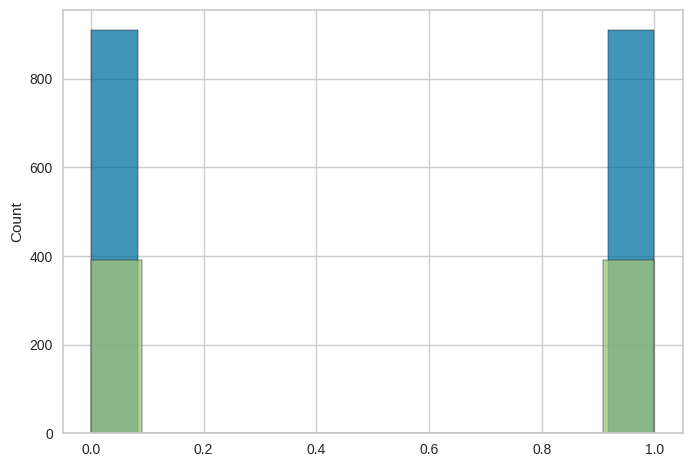

In [4]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [5]:
# Import necessary modules
import torch
import numpy as np
from tests.evaluate import TopKEvaluator

# Configure device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Define model configurations
model_configs = {
    'giftshifter': {
        'model_class': GIFTSHIFTER,
        'wrapper_class': SklearnGIFTSHIFTERWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }
} 

'''
'Litanfis': {
        'model_class': LitAnfis,
        'wrapper_class': SklearnLitAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 

'GIFTSHIFTENTROPY': {
        'model_class': GIFTSHIFTENTROPY,
        'wrapper_class': SklearnGIFTSHIFTENTROPYWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
            'entropy_coef': 0.0005
        }
    }


'GIFTSHIFT': {
        'model_class': GIFTSHIFT,
        'wrapper_class': SklearnGIFTSHIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

'giftshifter': {
        'model_class': GIFTSHIFTER,
        'wrapper_class': SklearnGIFTSHIFTERWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 
    
'Anfis': {
        'model_class': ANFIS,
        'wrapper_class': SklearnAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    },

'Unfis': {
        'model_class': UNFIS,
        'wrapper_class': SklearnAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    },

'Griffin': {
        'model_class': GRIFFIN,
        'wrapper_class': SklearnGRIFFINrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

'''


# Define learning parameters
learning_params = {
    'batch_size': 32,
    'lr': 0.005,
    'max_lr': 0.01,
    'epochs': 100,
    'alpha': 1.0,
    'min_alpha': 0.0
}

# Create evaluator instance
evaluator = TopKEvaluator(
    experiment=experiment,
    model_configs=model_configs,
    learning_params=learning_params,
    device=device,
    binary=binary,
    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    n_runs=100,
    top_k=30,
    ranking_metric="both",  # acc avg from top-k-by-acc, auc avg from top-k-by-auc
    random_state=None,  # random seed per run
    use_noise=False,   # Set to False for clean data only
    noise_type="gaussian"  # or "salt_pepper"
)

# Run evaluation
results_df = evaluator.evaluate(verbose=True)

# Print detailed report
evaluator.print_detailed_report()

# Plot results (only if noise is enabled)
if evaluator.use_noise:
    evaluator.plot_robustness_curves(save_path="robustness_curves.png")
    evaluator.plot_relative_performance(save_path="relative_performance.png")


🔇 NOISE IS DISABLED - Clean data evaluation only


Noise levels:   0%|          | 0/1 [00:00<?, ?it/s]


Testing: CLEAN DATA (σ = 0)

Training GIFTSHIFTER...
  Run 1/30... Acc=0.5749, LingRich=1.3266, RelaxRate=0.9022
  Run 2/30... Acc=0.5519, LingRich=1.3249, RelaxRate=0.8995
  Run 3/30... Acc=0.5544, LingRich=1.3421, RelaxRate=0.9030
  Run 4/30... Acc=0.5391, LingRich=1.3195, RelaxRate=0.8952
  Run 5/30... Acc=0.5531, LingRich=1.3381, RelaxRate=0.9014
  Run 6/30... Acc=0.5391, LingRich=1.3203, RelaxRate=0.8956
  Run 7/30... Acc=0.5519, LingRich=1.3501, RelaxRate=0.9067
  Run 8/30... Acc=0.5608, LingRich=1.3178, RelaxRate=0.8963
  Run 9/30... Acc=0.5544, LingRich=1.3393, RelaxRate=0.9029
  Run 10/30... Acc=0.5672, LingRich=1.3207, RelaxRate=0.8998
  Run 11/30... Acc=0.5506, LingRich=1.3339, RelaxRate=0.9008
  Run 12/30... Acc=0.5519, LingRich=1.3329, RelaxRate=0.8999
  Run 13/30... Acc=0.5327, LingRich=1.3179, RelaxRate=0.9034
  Run 14/30... Acc=0.5237, LingRich=1.3306, RelaxRate=0.8973
  Run 15/30... Acc=0.5570, LingRich=1.3348, RelaxRate=0.9022
  Run 16/30... Acc=0.5915, LingRich=1.33

Noise levels: 100%|██████████| 1/1 [14:31<00:00, 871.54s/it]

Acc=0.5493, LingRich=1.3094, RelaxRate=0.8950

MODEL EVALUATION REPORT
Dataset: Madelon
Noise Enabled: False
Number of runs per configuration: 30
Train/test split: fresh 70/30 redrawn each run (PyCaret session_id)

📊 PERFORMANCE SUMMARY:
-------------------------------------------------------------------------------------------------------------------------------------------------
Model           Noise σ    Test Acc ± Std       Best Acc   Test AUC ± Std       Best AUC   Ling. Richness ± Std   Relax. Rate ± Std   
-------------------------------------------------------------------------------------------------------------------------------------------------
GIFTSHIFTER     Clean      0.5520 ± 0.0157    0.5915     0.5690 ± 0.0140    0.5999     1.3317 ± 0.0103        0.9003 ± 0.0029     

📖 LINGUISTIC RICHNESS (clean data, higher = more relational diversity per rule):
    Shared absolute scale across ALL models — ceiling = log(4) = 1.3863 nats.
    H is directly comparable between models;

## Interpretability: rule regions & decision boundary (Haberman)

To show that the learned fuzzy rules genuinely partition the input space, we
project the Haberman data onto its two main features — **positive axillary
nodes vs age** — while holding every other feature fixed at its mean value.
A dense grid over these two features is fed to the trained model and each grid
point is coloured by (a) the **dominant rule** that fires there and (b) the
**predicted class**. The contiguous rule-coloured regions are visual proof that
the rules carve the space into interpretable areas, and the decision boundary
shows how those regions combine into a prediction.


Features -> x: num_imputer__positive_auxillary_nodes (idx 2), y: num_imputer__age (idx 0)
Haberman test accuracy: 0.7174


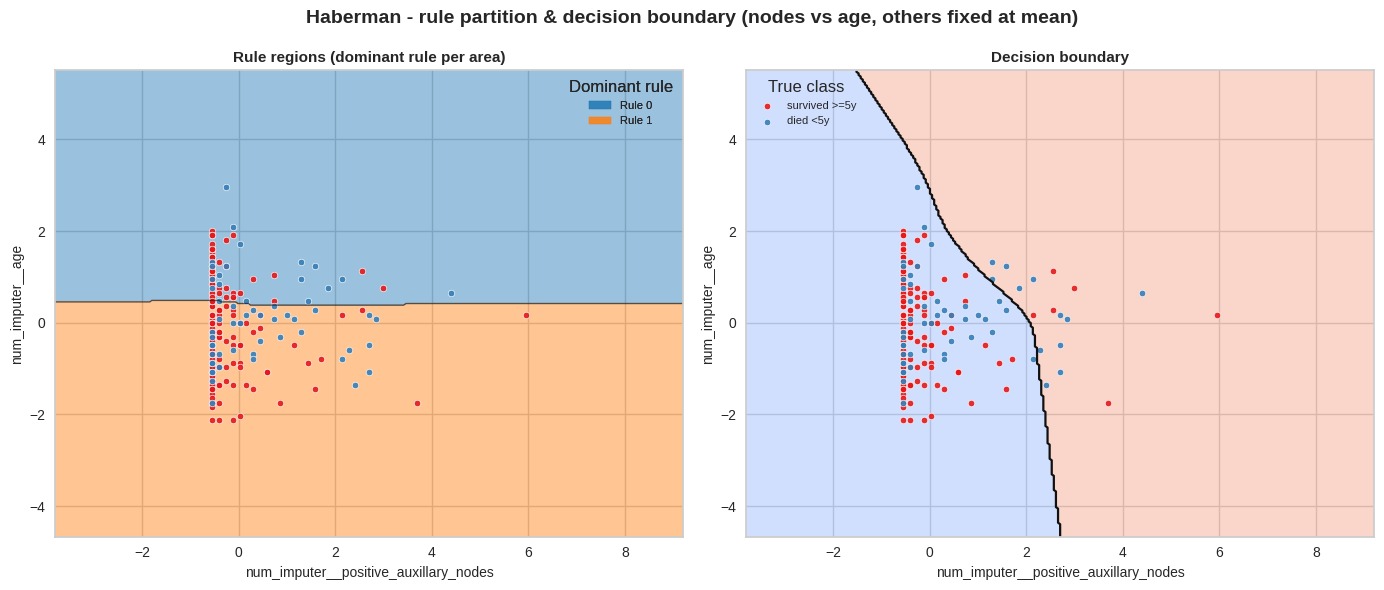

(<Figure size 1400x600 with 2 Axes>,
 array([<Axes: title={'center': 'Rule regions (dominant rule per area)'}, xlabel='num_imputer__positive_auxillary_nodes', ylabel='num_imputer__age'>,
        <Axes: title={'center': 'Decision boundary'}, xlabel='num_imputer__positive_auxillary_nodes', ylabel='num_imputer__age'>],
       dtype=object))

In [6]:
# interpretability-haberman

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

from tests.tabular_small import Haberman
from model.giftshifter import GIFTSHIFTER
from utils.decision_boundary import plot_interpretability_2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Haberman (data is standardized -> "mean value" of held-fixed features is ~0)
hab = Haberman(session_id=random_state)
X_train, y_train = hab.train_numpy()
X_test, y_test = hab.test_numpy()
feature_names = list(hab.clf.X_train_transformed.columns)
hab_binary = len(np.unique(y_train)) == 2


def _find_feature(names, *keywords, default=0):
    """Index of the first feature whose (lowercased) name contains all keywords."""
    for i, name in enumerate(names):
        low = name.lower()
        if all(k in low for k in keywords):
            return i
    return default


# The two "main" features requested: positive axillary nodes vs age.
idx_nodes = _find_feature(feature_names, "nod", default=2)
idx_age = _find_feature(feature_names, "age", default=0)
print(f"Features -> x: {feature_names[idx_nodes]} (idx {idx_nodes}), "
      f"y: {feature_names[idx_age]} (idx {idx_age})")

# Train a compact GIFTSHIFTER so the rule partition stays readable.
hab_rules = 2
model = GIFTSHIFTER(
    in_features=X_train.shape[1],
    rules=hab_rules,
    out_features=1 if hab_binary else len(np.unique(y_train)),
    binary=hab_binary,
    drop_out_p=0.3,
    dtype=torch.float32,
).to(device)

y_tensor = torch.tensor(y_train, dtype=torch.float32 if hab_binary else torch.long)
loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), y_tensor),
    batch_size=32, shuffle=True,
)

n_epochs = 150
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(loader), epochs=n_epochs)
l1 = nn.L1Loss()
task_loss = nn.BCEWithLogitsLoss() if hab_binary else nn.CrossEntropyLoss()

model.train()
for epoch in range(n_epochs):
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out, recon, _ = model(bx)
        if hab_binary:
            loss = task_loss(out.squeeze(), by.squeeze()) + l1(recon, bx)
        else:
            loss = task_loss(out, by.long()) + l1(recon, bx)
        loss.backward()
        optimizer.step()
        try:
            scheduler.step()
        except ValueError:
            pass
model.eval()

with torch.no_grad():
    logits = model(torch.tensor(X_test, dtype=torch.float32, device=device))[0]
    if hab_binary:
        pred = (torch.sigmoid(logits).squeeze() > 0.5).long().cpu().numpy()
    else:
        pred = logits.argmax(1).cpu().numpy()
print(f"Haberman test accuracy: {(pred == y_test).mean():.4f}")

class_names = ["survived >=5y", "died <5y"]
plot_interpretability_2d(
    model, X_train, y_train,
    feature_x=idx_nodes, feature_y=idx_age,
    feature_names=feature_names, class_names=class_names,
    resolution=300,
    suptitle="Haberman - rule partition & decision boundary (nodes vs age, others fixed at mean)",
)


### Relaxation heatmap (rules x features)

The consequent relaxation coefficient `r_{i,j}` has no 2D limitation, so we can
show all features at once as a `rules x features` matrix. **Dark cells** mean the
feature is fully **active** in that rule (`r ~ 0`), while **light cells** mean it
is **relaxed / ignored** (`r ~ 1`). This exposes, per rule, exactly which inputs
the model actually relies on.


<Axes: title={'center': 'Haberman - consequent relaxation r (dark = active, light = ignored)'}, xlabel='Feature', ylabel='Rule'>

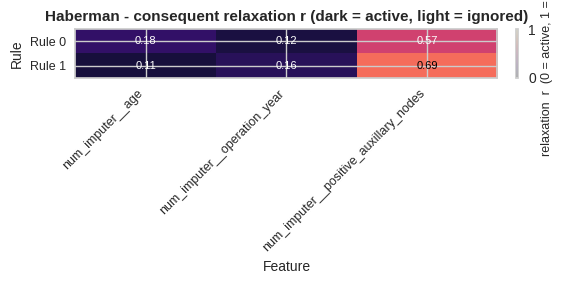

In [7]:
# relaxation-heatmap-haberman

from utils.relaxation import plot_relaxation_heatmap

plot_relaxation_heatmap(
    model,
    feature_names=feature_names,
    rule_names=[f"Rule {i}" for i in range(model.rules_count)],
    title="Haberman - consequent relaxation r (dark = active, light = ignored)",
)
